# Step 12 — Grid Search vs Bayesian TPE: Head-to-Head Comparison

Runs Grid Search over the same hyperparameter space as Step 11 (TPE),
then produces a direct comparison table and diagnostic plots.

**Required**: Steps 1–10 of `ae_estimation_ann.ipynb` must be in the kernel.
Run this cell first if opening this notebook standalone:

```python
%run ae_estimation_ann.ipynb
```

**What is being compared**

| Method | Strategy | Trials | n_segments search |
|---|---|---|---|
| Grid Search | Exhaustive, fixed grid | `n_layers × units × dropout × n_seg` combinations | Yes |
| Bayesian TPE | Surrogate-guided, adaptive | 80 | Yes |

The comparison metrics are: best validation loss, total wall-clock time,
number of trials, and final MAE / RMSE / R² on the test set.


## 12.0 · Load base notebook (Steps 1–10)

FileChooser(path='G:\Mi unidad\Exchange\MscCD\Measurements_CutOpt', filename='', title='', show_hidden=False, …

G:\Mi unidad\Exchange\MscCD\Measurements_CutOpt\Experiment_C4240.xlsx
Loaded: Experiment_C4240.xlsx
Loaded: G:\Mi unidad\Exchange\MscCD\Measurements_CutOpt\Experiment_C4240.xlsx
Ae (mm)                                     40
Ap (mm)                                    1.0
f (mm/min)                               505.6
N (rpm)                                 2108.0
R (mm)                                      20
Z                                            2
fz                                    0.119924
Vc                                  264.899093
SinuTraceFile (*.csv)    Trace_0624_093843.csv
Name: 32, dtype: object
 
Index(['time', '+/Nck/!SD/nckServoDataActCurr32 [u1; 1]',
       '+/Nck/!SD/nckServoDataActCurr32 [u1; 2]',
       '+/Nck/!SD/nckServoDataActCurr32 [u1; 4]',
       '+/Nck/!SD/nckServoDataActPos1stEnc32 [u1; 2]',
       '+/Nck/!SD/nckServoDataActPos1stEnc32 [u1; 3]',
       '+/Nck/!SD/nckServoDataActVelMot32 [u1; 4]',
       '+/Channel/!RP/rpa [u1; 15]', '+/Nck/!SD/nckSe

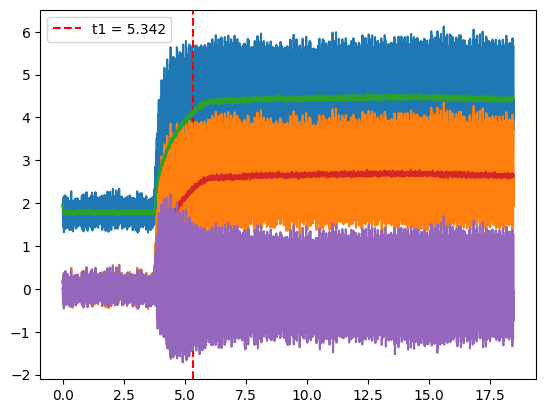

=== Dataset shapes ===
X shape : (256, 13)
y shape : (256,)
X_train : (204, 13)  |  X_test : (52, 13)

=== Target ae [mm] ===
min=26.000  max=40.000  mean=34.000  std=5.477
unique values: [26. 32. 38. 40.]

=== Feature matrix (unscaled) ===
            rms      peak     crest  mean_rect       std  mean_rev_mean  \
count  256.0000  256.0000  256.0000   256.0000  256.0000       256.0000   
mean     0.9405    2.0142    2.1536     0.8058    0.9405        -0.0021   
std      0.1646    0.3186    0.1671     0.1501    0.1646         0.0049   
min      0.4070    1.0759    1.7818     0.3519    0.4070        -0.0323   
25%      0.8261    1.7981    2.0435     0.6968    0.8259        -0.0027   
50%      0.9238    2.0006    2.1207     0.7874    0.9238        -0.0004   
75%      1.0481    2.2230    2.2197     0.9062    1.0481         0.0008   
max      1.4398    2.8711    2.9463     1.2778    1.4398         0.0091   

       mean_rev_max  std_rev_max  tooth_energy   Mc_norm        ap        fz  \
cou

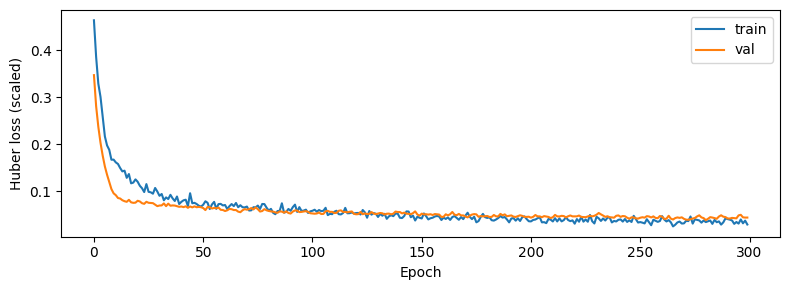

MAE  = 1.2568 mm
RMSE = 1.6450 mm
R²   = 0.9014


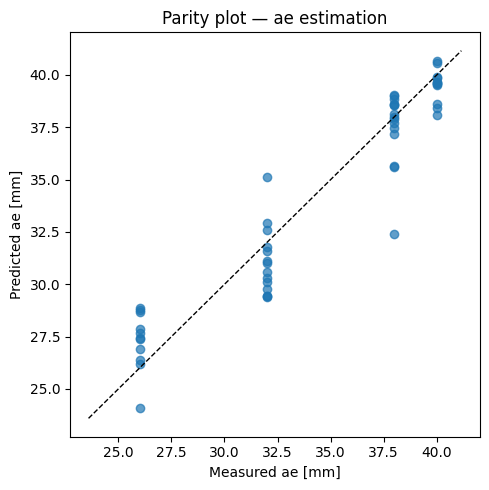

True ae=38.00  |  Predicted 38.80 ± 0.029 mm
True ae=38.00  |  Predicted 37.07 ± 0.019 mm
True ae=26.00  |  Predicted 24.34 ± 0.066 mm
True ae=26.00  |  Predicted 27.33 ± 0.037 mm
True ae=38.00  |  Predicted 38.04 ± 0.023 mm
True ae=32.00  |  Predicted 31.00 ± 0.024 mm
True ae=40.00  |  Predicted 39.60 ± 0.027 mm
True ae=38.00  |  Predicted 39.05 ± 0.026 mm
True ae=32.00  |  Predicted 30.13 ± 0.020 mm
True ae=26.00  |  Predicted 27.08 ± 0.056 mm
True ae=38.00  |  Predicted 38.55 ± 0.024 mm
True ae=26.00  |  Predicted 28.85 ± 0.033 mm
True ae=38.00  |  Predicted 37.38 ± 0.027 mm
True ae=32.00  |  Predicted 32.56 ± 0.028 mm
True ae=32.00  |  Predicted 29.55 ± 0.037 mm
True ae=38.00  |  Predicted 37.93 ± 0.029 mm
True ae=38.00  |  Predicted 35.50 ± 0.022 mm
True ae=26.00  |  Predicted 28.65 ± 0.031 mm
True ae=40.00  |  Predicted 40.65 ± 0.036 mm
True ae=32.00  |  Predicted 30.97 ± 0.044 mm
True ae=32.00  |  Predicted 35.10 ± 0.029 mm
True ae=40.00  |  Predicted 39.53 ± 0.031 mm
True ae=32

In [2]:
# Executes all cells in the base notebook and injects all globals here.
# Comment out if you already have the kernel state from ae_estimation_ann.ipynb.

#ae_estimation_step11_tpe.ipynb calls ae_estimattion_ann.ipynb
%run ae_estimation_ann.ipynb
#%run ae_estimation_step11_tpe.ipynb


## 12.1 · Imports

In [3]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from itertools import product as iterproduct
import time
import matplotlib.pyplot as plt
import optuna
from optuna.samplers import TPESampler
from optuna.pruners import HyperbandPruner

optuna.logging.set_verbosity(optuna.logging.WARNING)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")


Device: cpu


## 12.2 · Shared hyperparameter space

Both methods search the **identical space** — the only difference is *how*
they explore it. Grid Search evaluates every combination; TPE focuses
compute on the most promising regions.

Adjust the grid values below to control the combinatorial explosion.
The defaults give `3 × 3 × 4 × 4 = 144 Grid Search trials`.


In [4]:
# ── shared search space (identical for both methods) ─────────────────────
GRID = {
    "n_layers":   [1, 2, 3],           # 3 options
    "units":      [32, 64, 128],        # 3 options — uniform width per layer
    "dropout":    [0.05, 0.15, 0.30, 0.45],  # 4 options
    "n_segments": [2, 4, 5, 6, 7, 8],        # 6 options
}

N_EPOCHS   = 150    # per trial (same budget for both methods)
N_TPE      = 80     # number of TPE trials
INPUT_DIM  = X_train_sc.shape[1]   # 13 features

n_grid_trials = 1
for v in GRID.values():
    n_grid_trials *= len(v)
print(f"Grid Search trials : {n_grid_trials}")
print(f"TPE trials         : {N_TPE}")
print(f"Epochs per trial   : {N_EPOCHS}")


Grid Search trials : 216
TPE trials         : 80
Epochs per trial   : 150


## 12.3 · Shared helpers

Segment rebuild and training loop — identical to Step 11 so both methods
run under exactly the same conditions.


In [ ]:
def build_scaled_splits_for_n_seg(n_segments: int, random_state: int = 42):
    """Re-segment cuts and return scaled train/test splits (mirrors Step 11)."""
    ds_local = []
    for idx in range(len(cut_param)):
        csv_path = data_file_path + "\\all\\" + df_info["SinuTraceFile (*.csv)"][idx]
        df_raw   = pd.read_csv(csv_path)
        cpp      = cut_param.iloc[idx]
        f        = cpp["f (mm/min)"]
        r_tool   = cpp["R (mm)"]
        Nrpm     = cpp['N (rpm)']        

        t_ramp_up     = (2 * r_tool + 5) / f * 60
        idx_start     = np.argmax(df_raw["time"] > t_ramp_up)
        t_friction    = (r_tool + 5) / f * 60
        idx_frict     = np.argmax(df_raw["time"] > t_friction)
        col           = "+/Nck/!SD/nckServoDataActCurr32 [u1; 4]"
        mean_iq_frict = np.mean(df_raw[col][:idx_frict])
        
        # --- extract static bending ---
        fs = 500
        ns = round(fs / (Nrpm/60))
        iq_maf = msu.maf(df_raw[col], ns)
        df_raw[col] = df_raw[col] - iq_maf
        
        iq_eval = np.asarray(df_raw[col][idx_start:], dtype=float)
        # --- END extract static bending ---

        #iq_eval       = np.asarray(df_raw[col][idx_start:] - mean_iq_frict, dtype=float)

        seg_len = len(iq_eval) // n_segments
        if seg_len == 0:
            continue
        segs = iq_eval[:seg_len * n_segments].reshape(n_segments, seg_len)
        for seg in segs:
            ds_local.append({
                "signal": seg,
                "ap":  float(cpp["Ap (mm)"]),
                "fz":  float(cpp["fz"]),
                "n":   float(cpp["N (rpm)"]),
                "D":   float(2 * cpp["R (mm)"]),
                "z":   float(cpp["Z"]),
                "ae":  float(cpp["Ae (mm)"]),
                "mean_iq_frict": float(mean_iq_frict),
            })

    X_loc = np.array([
        build_feature_vector(s, KC11_NOMINAL, MC_NOMINAL, FS) for s in ds_local
    ])
    y_loc = np.array([s["ae"] for s in ds_local])
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_loc, y_loc, test_size=0.2, random_state=random_state
    )
    return (
        scaler_X.transform(X_tr), scaler_X.transform(X_te),
        scaler_y.transform(y_tr.reshape(-1,1)).ravel(),
        scaler_y.transform(y_te.reshape(-1,1)).ravel()
    )


def train_and_evaluate(model, X_tr, y_tr, X_te, y_te,
                        n_epochs=150, batch_size=16, lr=1e-3,
                        trial=None):
    """
    Train model, return (best_val_loss, final_val_loss).
    Optionally reports to Optuna trial for pruning.
    """
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    criterion = nn.HuberLoss(delta=1.0)
    tr_loader  = DataLoader(MillingDataset(X_tr, y_tr),
                            batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(MillingDataset(X_te, y_te),
                            batch_size=len(X_te))
    best_val = float("inf")
    for epoch in range(n_epochs):
        model.train()
        for X_b, y_b in tr_loader:
            optimizer.zero_grad()
            criterion(model(X_b), y_b).backward()
            optimizer.step()
        model.eval()
        with torch.no_grad():
            for X_v, y_v in val_loader:
                val_loss = criterion(model(X_v), y_v).item()
        best_val = min(best_val, val_loss)
        if trial is not None:
            trial.report(val_loss, epoch)
            if trial.should_prune():
                raise optuna.exceptions.TrialPruned()
    return best_val

print("Helpers ready.")


Helpers ready.


## 12.4 · Grid Search

Evaluates every combination in `GRID` exhaustively.
Note: `units` applies uniformly to all layers — `[64, 64]` for `n_layers=2`,
`[64, 64, 64]` for `n_layers=3`. This is a deliberate simplification that
keeps the grid tractable; TPE searches per-layer widths independently.

> **Wall-clock warning**: at 144 trials × 150 epochs this can take
> 15–40 minutes on CPU. Reduce `N_EPOCHS` or the grid values above to speed up.


In [6]:
grid_results = []   # list of dicts — one per combination

keys   = list(GRID.keys())
combos = list(iterproduct(*[GRID[k] for k in keys]))
n_total = len(combos)

print(f"Starting Grid Search: {n_total} combinations x {N_EPOCHS} epochs each")
t_grid_start = time.time()

for trial_i, combo in enumerate(combos):
    params = dict(zip(keys, combo))

    # build data for this segment count
    X_tr, X_te, y_tr, y_te = build_scaled_splits_for_n_seg(params["n_segments"])

    # uniform-width hidden layers
    hidden = [params["units"]] * params["n_layers"]

    model = AeEstimatorMLP(
        n_features=INPUT_DIM,
        hidden=hidden,
        dropout=params["dropout"]
    ).to(DEVICE)

    val_loss = train_and_evaluate(
        model, X_tr, y_tr, X_te, y_te, n_epochs=N_EPOCHS
    )

    grid_results.append({**params, "val_loss": val_loss, "hidden": hidden})

    if (trial_i + 1) % 10 == 0 or trial_i == 0:
        elapsed = time.time() - t_grid_start
        eta = elapsed / (trial_i + 1) * (n_total - trial_i - 1)
        print(f"  [{trial_i+1:3d}/{n_total}]  "
              f"params={params}  val_loss={val_loss:.5f}  "
              f"elapsed={elapsed:.0f}s  ETA={eta:.0f}s")

t_grid_total = time.time() - t_grid_start
print(f"Grid Search done in {t_grid_total:.1f} s")

gs_df = pd.DataFrame(grid_results).sort_values("val_loss")
gs_best = gs_df.iloc[0]
print(f"\nBest Grid Search result:")
print(gs_best.to_string())


Starting Grid Search: 216 combinations x 150 epochs each


AttributeError: 'Series' object has no attribute 'reshape'

## 12.5 · Bayesian TPE Search

Searches the same space with `n_trials=N_TPE` adaptive trials.
Per-layer widths are searched independently (more expressive than the
uniform-width constraint in Grid Search).


In [ ]:
def tpe_objective(trial):
    n_layers = trial.suggest_int("n_layers", min(GRID["n_layers"]),
                                             max(GRID["n_layers"]))
    # per-layer widths — TPE can find tapered architectures Grid Search cannot
    hidden   = [
        trial.suggest_int(f"units_l{i}", min(GRID["units"]),
                                          max(GRID["units"]), step=32)
        for i in range(n_layers)
    ]
    dropout  = trial.suggest_float("dropout",
                                    min(GRID["dropout"]),
                                    max(GRID["dropout"]))
    n_seg    = trial.suggest_int("n_segments", min(GRID["n_segments"]),
                                               max(GRID["n_segments"]))

    X_tr, X_te, y_tr, y_te = build_scaled_splits_for_n_seg(n_seg)
    model = AeEstimatorMLP(
        n_features=INPUT_DIM, hidden=hidden, dropout=dropout
    ).to(DEVICE)
    return train_and_evaluate(
        model, X_tr, y_tr, X_te, y_te,
        n_epochs=N_EPOCHS, trial=trial
    )


print(f"Starting TPE Search: {N_TPE} trials x up to {N_EPOCHS} epochs each")
t_tpe_start = time.time()

study = optuna.create_study(
    direction="minimize",
    study_name="ae_mlp_tpe_compare",
    sampler=TPESampler(n_startup_trials=20, multivariate=True, seed=42),
    pruner=HyperbandPruner(min_resource=10, max_resource=N_EPOCHS,
                           reduction_factor=3),
)
study.optimize(tpe_objective, n_trials=N_TPE,
               show_progress_bar=True, gc_after_trial=True)

t_tpe_total = time.time() - t_tpe_start
print(f"TPE done in {t_tpe_total:.1f} s")
print(f"Best TPE val loss : {study.best_value:.6f}")
print(f"Best TPE params   : {study.best_params}")


Starting TPE Search: 80 trials x up to 150 epochs each


c:\Users\thmru\github\2026_EstanciaInvestigacion_PTW\ae_estim\Lib\site-packages\optuna\_experimental.py:33: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  optuna_warn(


  0%|          | 0/80 [00:00<?, ?it/s]

TPE done in 170.0 s
Best TPE val loss : 0.003104
Best TPE params   : {'n_layers': 3, 'units_l0': 128, 'units_l1': 128, 'units_l2': 128, 'dropout': 0.056833353774605494, 'n_segments': 6}


## 12.6 · Side-by-side comparison

Both methods are retrained at their best hyperparameters with 300 epochs
and evaluated with MC Dropout on the same held-out test set.


In [ ]:
def retrain_and_score(hidden, dropout, n_seg, label):
    """Retrain at given hyperparams (300 epochs, full data) and return metrics dict."""
    X_tr, X_te, y_tr, y_te = build_scaled_splits_for_n_seg(n_seg)
    X_full = np.concatenate([X_tr, X_te])
    y_full = np.concatenate([y_tr, y_te])

    model = AeEstimatorMLP(
        n_features=INPUT_DIM, hidden=hidden, dropout=dropout
    ).to(DEVICE)
    train_and_evaluate(model, X_full, y_full, X_te, y_te, n_epochs=300)

    x_te_t = torch.tensor(X_te, dtype=torch.float32).to(DEVICE)
    ae_mean, ae_std = mc_predict(model, x_te_t)
    y_te_phys = scaler_y.inverse_transform(y_te.reshape(-1,1)).ravel()

    return {
        "method":     label,
        "hidden":     str(hidden),
        "dropout":    round(dropout, 3),
        "n_segments": n_seg,
        "MAE":        round(mean_absolute_error(y_te_phys, ae_mean), 4),
        "RMSE":       round(float(np.sqrt(np.mean((y_te_phys - ae_mean)**2))), 4),
        "R2":         round(r2_score(y_te_phys, ae_mean), 4),
        "mean_uncertainty": round(float(ae_std.mean()), 4),
    }, model, X_te, y_te


# ── Grid Search best params ───────────────────────────────────────────────
gs_hidden = gs_best["hidden"]
gs_dropout = float(gs_best["dropout"])
gs_nseg   = int(gs_best["n_segments"])

# ── TPE best params ───────────────────────────────────────────────────────
tp = study.best_params
tpe_n_lay = tp["n_layers"]
tpe_hidden = [tp[f"units_l{i}"] for i in range(tpe_n_lay)]
tpe_dropout = tp["dropout"]
tpe_nseg    = tp["n_segments"]

print("Retraining Grid Search best model (300 epochs)...")
gs_metrics, gs_model, gs_Xte, gs_yte = retrain_and_score(
    gs_hidden, gs_dropout, gs_nseg, "Grid Search"
)

print("Retraining TPE best model (300 epochs)...")
tpe_metrics, tpe_model, tpe_Xte, tpe_yte = retrain_and_score(
    tpe_hidden, tpe_dropout, tpe_nseg, "Bayesian TPE"
)

# ── summary table ────────────────────────────────────────────────────────
compare_df = pd.DataFrame([
    {**gs_metrics,
     "trials":       len(combos),
     "time_s":       round(t_grid_total, 1),
     "best_val_loss": round(float(gs_best["val_loss"]), 6)},
    {**tpe_metrics,
     "trials":       N_TPE,
     "time_s":       round(t_tpe_total, 1),
     "best_val_loss": round(study.best_value, 6)},
])

print("\n" + "="*60)
print("COMPARISON SUMMARY")
print("="*60)
print(compare_df.to_string(index=False))


Retraining Grid Search best model (300 epochs)...
Retraining TPE best model (300 epochs)...

COMPARISON SUMMARY
      method          hidden  dropout  n_segments    MAE   RMSE     R2  mean_uncertainty  trials  time_s  best_val_loss
 Grid Search [128, 128, 128]    0.150           8 0.1988 0.2990 0.9969            0.0135     216   700.5       0.002862
Bayesian TPE [128, 128, 128]    0.057           6 0.2195 0.2747 0.9976            0.0087      80   170.0       0.003104


## 12.7 · Diagnostic plots

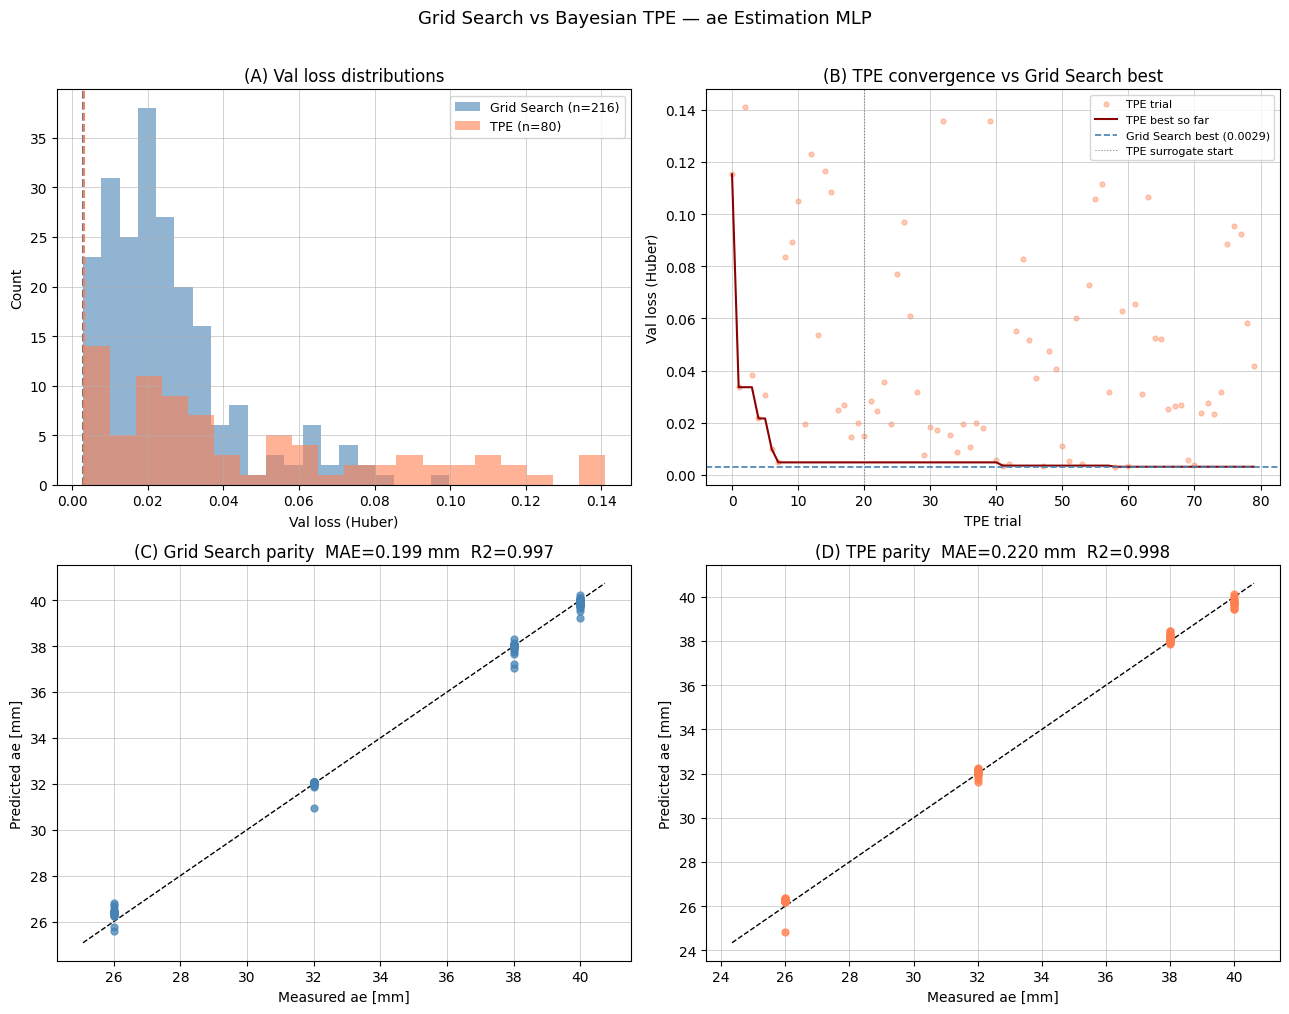

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# ── (A) val loss distributions ───────────────────────────────────────────
ax = axes[0, 0]
gs_losses  = gs_df["val_loss"].values
tpe_losses = [t.value for t in study.trials if t.value is not None]
ax.hist(gs_losses,  bins=20, alpha=0.6, color="steelblue", label=f"Grid Search (n={len(gs_losses)})")
ax.hist(tpe_losses, bins=20, alpha=0.6, color="coral",     label=f"TPE (n={len(tpe_losses)})")
ax.axvline(gs_df["val_loss"].min(),  color="steelblue", ls="--", lw=1.5)
ax.axvline(min(tpe_losses),          color="coral",     ls="--", lw=1.5)
ax.set_xlabel("Val loss (Huber)"); ax.set_ylabel("Count")
ax.set_title("(A) Val loss distributions")
ax.legend(fontsize=9); ax.grid(True, lw=0.4)

# ── (B) TPE optimisation history ─────────────────────────────────────────
ax = axes[0, 1]
best_so_far = [min(tpe_losses[:i+1]) for i in range(len(tpe_losses))]
ax.scatter(range(len(tpe_losses)), tpe_losses,
           s=12, alpha=0.4, color="coral", label="TPE trial")
ax.plot(best_so_far, color="darkred", lw=1.5, label="TPE best so far")
ax.axhline(gs_df["val_loss"].min(), color="steelblue", ls="--", lw=1.2,
           label=f"Grid Search best ({gs_df['val_loss'].min():.4f})")
ax.axvline(20, color="gray", ls=":", lw=0.8, label="TPE surrogate start")
ax.set_xlabel("TPE trial"); ax.set_ylabel("Val loss (Huber)")
ax.set_title("(B) TPE convergence vs Grid Search best")
ax.legend(fontsize=8); ax.grid(True, lw=0.4)

# ── (C) parity plot — Grid Search ────────────────────────────────────────
ax = axes[1, 0]
x_te_t  = torch.tensor(gs_Xte, dtype=torch.float32).to(DEVICE)
gs_mean, gs_std = mc_predict(gs_model, x_te_t)
y_phys_gs = scaler_y.inverse_transform(gs_yte.reshape(-1,1)).ravel()
lims = [min(y_phys_gs.min(), gs_mean.min()) - 0.5,
        max(y_phys_gs.max(), gs_mean.max()) + 0.5]
ax.plot(lims, lims, "k--", lw=1)
ax.errorbar(y_phys_gs, gs_mean, yerr=1.96 * gs_std,
            fmt="o", ms=5, alpha=0.7, color="steelblue",
            ecolor="lightblue", elinewidth=0.8, capsize=2)
ax.set_xlabel("Measured ae [mm]"); ax.set_ylabel("Predicted ae [mm]")
ax.set_title(f"(C) Grid Search parity  MAE={gs_metrics['MAE']:.3f} mm  R2={gs_metrics['R2']:.3f}")
ax.grid(True, lw=0.4)

# ── (D) parity plot — TPE ────────────────────────────────────────────────
ax = axes[1, 1]
x_te_t   = torch.tensor(tpe_Xte, dtype=torch.float32).to(DEVICE)
tpe_mean, tpe_std = mc_predict(tpe_model, x_te_t)
y_phys_tpe = scaler_y.inverse_transform(tpe_yte.reshape(-1,1)).ravel()
lims = [min(y_phys_tpe.min(), tpe_mean.min()) - 0.5,
        max(y_phys_tpe.max(), tpe_mean.max()) + 0.5]
ax.plot(lims, lims, "k--", lw=1)
ax.errorbar(y_phys_tpe, tpe_mean, yerr=1.96 * tpe_std,
            fmt="o", ms=5, alpha=0.7, color="coral",
            ecolor="lightsalmon", elinewidth=0.8, capsize=2)
ax.set_xlabel("Measured ae [mm]"); ax.set_ylabel("Predicted ae [mm]")
ax.set_title(f"(D) TPE parity  MAE={tpe_metrics['MAE']:.3f} mm  R2={tpe_metrics['R2']:.3f}")
ax.grid(True, lw=0.4)

plt.suptitle("Grid Search vs Bayesian TPE — ae Estimation MLP", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("gs_vs_tpe_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


## 12.8 · Grid Search landscape

Heatmaps of mean val loss across the grid axes — useful for understanding
where the grid is sensitive and where it is flat.


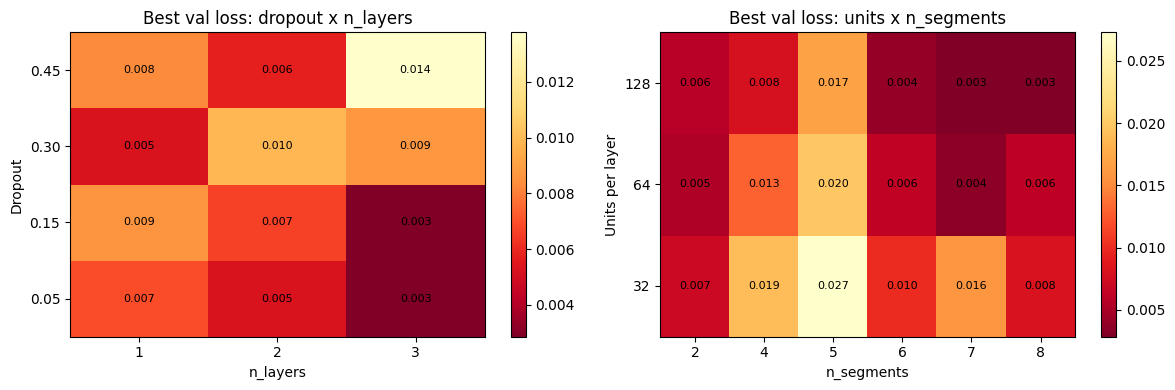

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ── dropout vs n_layers heatmap (mean over units and n_segments) ─────────
pivot1 = gs_df.pivot_table(
    values="val_loss", index="dropout", columns="n_layers", aggfunc="min"
)
im1 = axes[0].imshow(pivot1.values, aspect="auto", cmap="YlOrRd_r",
                     origin="lower")
axes[0].set_xticks(range(len(pivot1.columns)))
axes[0].set_xticklabels(pivot1.columns)
axes[0].set_yticks(range(len(pivot1.index)))
axes[0].set_yticklabels([f"{v:.2f}" for v in pivot1.index])
axes[0].set_xlabel("n_layers"); axes[0].set_ylabel("Dropout")
axes[0].set_title("Best val loss: dropout x n_layers")
plt.colorbar(im1, ax=axes[0])
for i in range(len(pivot1.index)):
    for j in range(len(pivot1.columns)):
        axes[0].text(j, i, f"{pivot1.values[i,j]:.3f}",
                    ha="center", va="center", fontsize=8, color="black")

# ── units vs n_segments heatmap (mean over dropout and n_layers) ─────────
pivot2 = gs_df.pivot_table(
    values="val_loss", index="units", columns="n_segments", aggfunc="min"
)
im2 = axes[1].imshow(pivot2.values, aspect="auto", cmap="YlOrRd_r",
                     origin="lower")
axes[1].set_xticks(range(len(pivot2.columns)))
axes[1].set_xticklabels(pivot2.columns)
axes[1].set_yticks(range(len(pivot2.index)))
axes[1].set_yticklabels(pivot2.index)
axes[1].set_xlabel("n_segments"); axes[1].set_ylabel("Units per layer")
axes[1].set_title("Best val loss: units x n_segments")
plt.colorbar(im2, ax=axes[1])
for i in range(len(pivot2.index)):
    for j in range(len(pivot2.columns)):
        axes[1].text(j, i, f"{pivot2.values[i,j]:.3f}",
                    ha="center", va="center", fontsize=8, color="black")

plt.tight_layout()
plt.savefig("gs_landscape_heatmaps.png", dpi=150, bbox_inches="tight")
plt.show()


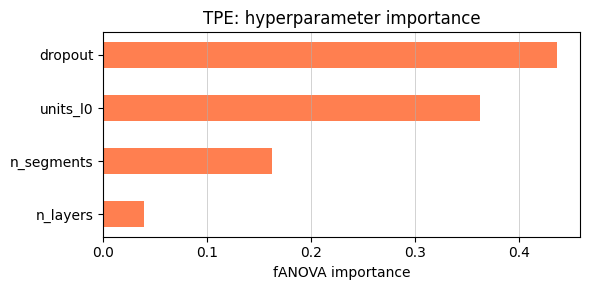

In [ ]:
# fANOVA importance for TPE study
try:
    importances = optuna.importance.get_param_importances(study)
    imp_df = pd.DataFrame({
        "param":      list(importances.keys()),
        "importance": list(importances.values())
    }).sort_values("importance")

    fig, ax = plt.subplots(figsize=(6, 3))
    ax.barh(imp_df["param"], imp_df["importance"],
            color="coral", height=0.5)
    ax.set_xlabel("fANOVA importance")
    ax.set_title("TPE: hyperparameter importance")
    ax.grid(True, axis="x", lw=0.4)
    plt.tight_layout(); plt.show()
except Exception as e:
    print(f"fANOVA unavailable: {e}")


## 12.9 · Save results

In [ ]:
import joblib

# print final comparison one more time
print("\n" + "="*60)
print("FINAL COMPARISON")
print("="*60)
cols_order = ["method", "hidden", "dropout", "n_segments",
              "trials", "time_s", "best_val_loss", "MAE", "RMSE", "R2",
              "mean_uncertainty"]
print(compare_df[cols_order].to_string(index=False))

# interpretation guidance
winner = compare_df.loc[compare_df["MAE"].idxmin(), "method"]
gs_row  = compare_df[compare_df["method"] == "Grid Search"].iloc[0]
tpe_row = compare_df[compare_df["method"] == "Bayesian TPE"].iloc[0]
speedup = gs_row["time_s"] / tpe_row["time_s"]
mae_diff = gs_row["MAE"] - tpe_row["MAE"]
print(f"\nWinner by MAE       : {winner}")
print(f"TPE speedup         : {speedup:.1f}x faster than Grid Search")
print(f"MAE difference      : {abs(mae_diff):.4f} mm  (TPE - Grid Search)")

# save
compare_df.to_csv("gs_vs_tpe_results.csv", index=False)
gs_df.to_csv("gs_all_trials.csv", index=False)
joblib.dump(study, "ae_mlp_tpe_comparison_study.pkl")

torch.save({
    "model_state_dict": gs_model.state_dict(),
    "hidden_dims": gs_hidden, "dropout": gs_dropout,
    "n_segments": gs_nseg, "method": "grid_search"
}, "ae_mlp_gridsearch_best.pt")

torch.save({
    "model_state_dict": tpe_model.state_dict(),
    "hidden_dims": tpe_hidden, "dropout": tpe_dropout,
    "n_segments": tpe_nseg, "method": "tpe"
}, "ae_mlp_tpe_best.pt")

print("\nSaved:")
print("  gs_vs_tpe_results.csv")
print("  gs_all_trials.csv")
print("  ae_mlp_gridsearch_best.pt")
print("  ae_mlp_tpe_best.pt")
print("  ae_mlp_tpe_comparison_study.pkl")



FINAL COMPARISON
      method          hidden  dropout  n_segments  trials  time_s  best_val_loss    MAE   RMSE     R2  mean_uncertainty
 Grid Search [128, 128, 128]    0.150           8     216   700.5       0.002862 0.1988 0.2990 0.9969            0.0135
Bayesian TPE [128, 128, 128]    0.057           6      80   170.0       0.003104 0.2195 0.2747 0.9976            0.0087

Winner by MAE       : Grid Search
TPE speedup         : 4.1x faster than Grid Search
MAE difference      : 0.0207 mm  (TPE - Grid Search)

Saved:
  gs_vs_tpe_results.csv
  gs_all_trials.csv
  ae_mlp_gridsearch_best.pt
  ae_mlp_tpe_best.pt
  ae_mlp_tpe_comparison_study.pkl
